In [1]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.append(str(project_root))

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

from src.utils.ucf101_grouped_classes import ucf101_categories_camelcase
from src.utils.constants import RESULTS_DIR

df = pd.read_csv(RESULTS_DIR / "test_results.csv")

In [3]:
df.head()

,clip_name,clip_path,label,frame_count,duration_sec,fps,width,height,resolution,MGSampler64_MeanPooling_TemplatePrompts
0,v_ApplyEyeMakeup_g01_c01,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c01.avi,ApplyEyeMakeup,164,6.56,25.0,320,240,320x240,ApplyEyeMakeup
1,v_ApplyEyeMakeup_g01_c02,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c02.avi,ApplyEyeMakeup,123,4.92,25.0,320,240,320x240,ApplyEyeMakeup
2,v_ApplyEyeMakeup_g01_c03,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c03.avi,ApplyEyeMakeup,259,10.36,25.0,320,240,320x240,ApplyEyeMakeup
3,v_ApplyEyeMakeup_g01_c04,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c04.avi,ApplyEyeMakeup,235,9.40,25.0,320,240,320x240,ApplyEyeMakeup
4,v_ApplyEyeMakeup_g01_c05,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c05.avi,ApplyEyeMakeup,296,11.84,25.0,320,240,320x240,ApplyEyeMakeup


In [4]:
pred = "MGSampler64_MeanPooling_TemplatePrompts"
label_col = "label"
classes = sorted(df[label_col].unique())


y_true = df[label_col]
y_pred = df[pred]

print("Template accuracy:", accuracy_score(y_true, y_pred))
print("MPVR macro-F1:", f1_score(y_true, y_pred, average="macro"))


Template accuracy: 0.6278086174993391
MPVR macro-F1: 0.5734791507129804


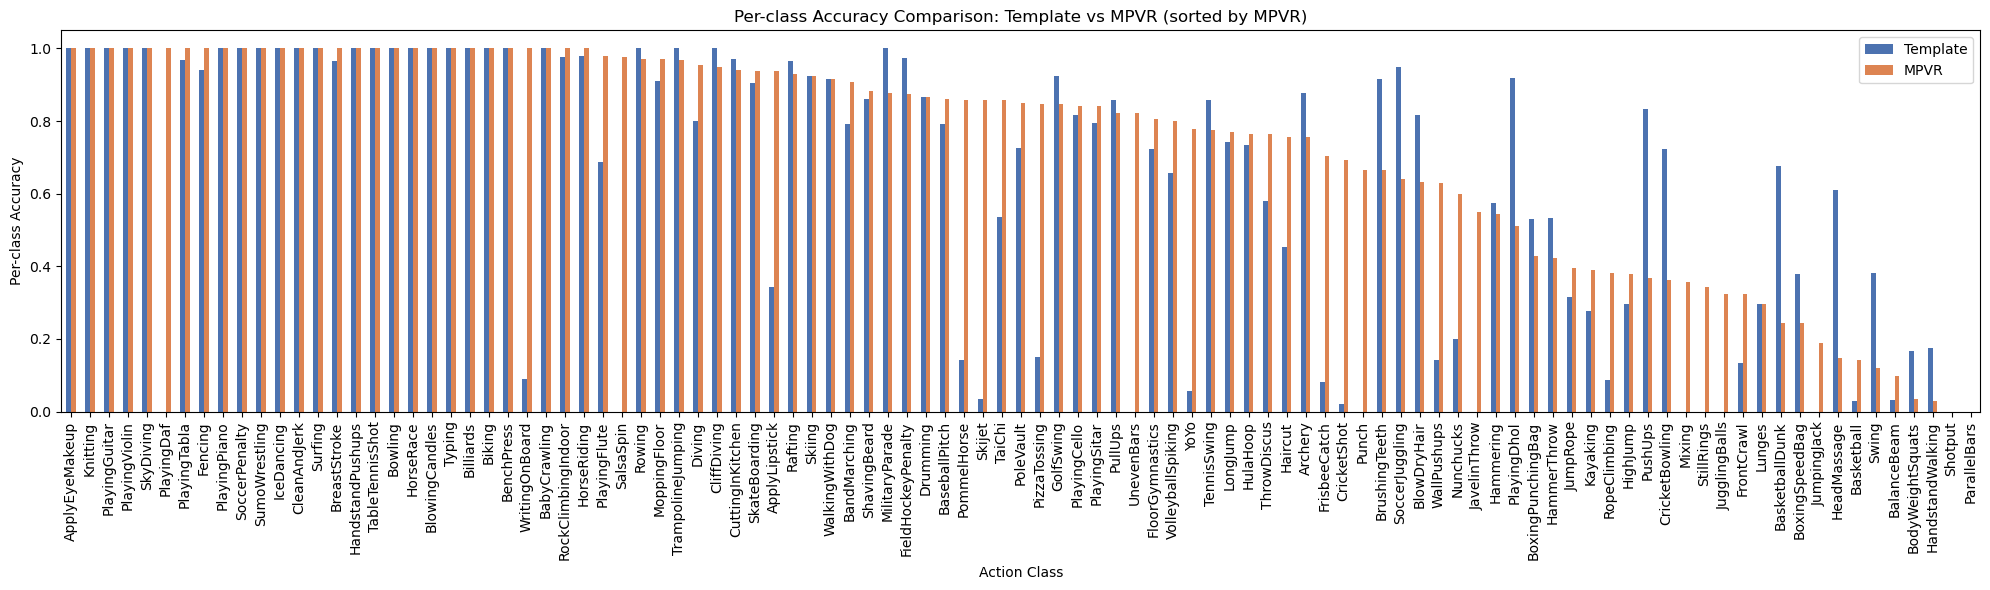

In [5]:
import pandas as pd

per_class_acc_temp = df.groupby(label_col)[pred_templates].apply(
    lambda x: (x == df.loc[x.index, label_col]).mean()
)
per_class_acc_mpvr = df.groupby(label_col)[pred_mpvr].apply(
    lambda x: (x == df.loc[x.index, label_col]).mean()
)

acc_df = pd.DataFrame({"Template": per_class_acc_temp, "MPVR": per_class_acc_mpvr})

acc_df = acc_df.sort_values("MPVR", ascending=False)

template_color = "#4c72b0"
mpvr_color = "#dd8452"

colors = [template_color, mpvr_color] * len(acc_df)

ax = acc_df.plot(
    kind="bar", figsize=(20, 6), color=[template_color, mpvr_color] * len(acc_df)
)
ax.set_ylabel("Per-class Accuracy")
ax.set_xlabel("Action Class")
ax.set_title("Per-class Accuracy Comparison: Template vs MPVR (sorted by MPVR)")
plt.tight_layout()
plt.show()


## Confusion Matrix

The confusion matrix generated by the code below shows the probability that a true label is predicted as another label (based on the column). Row probabilities sum to 100%.

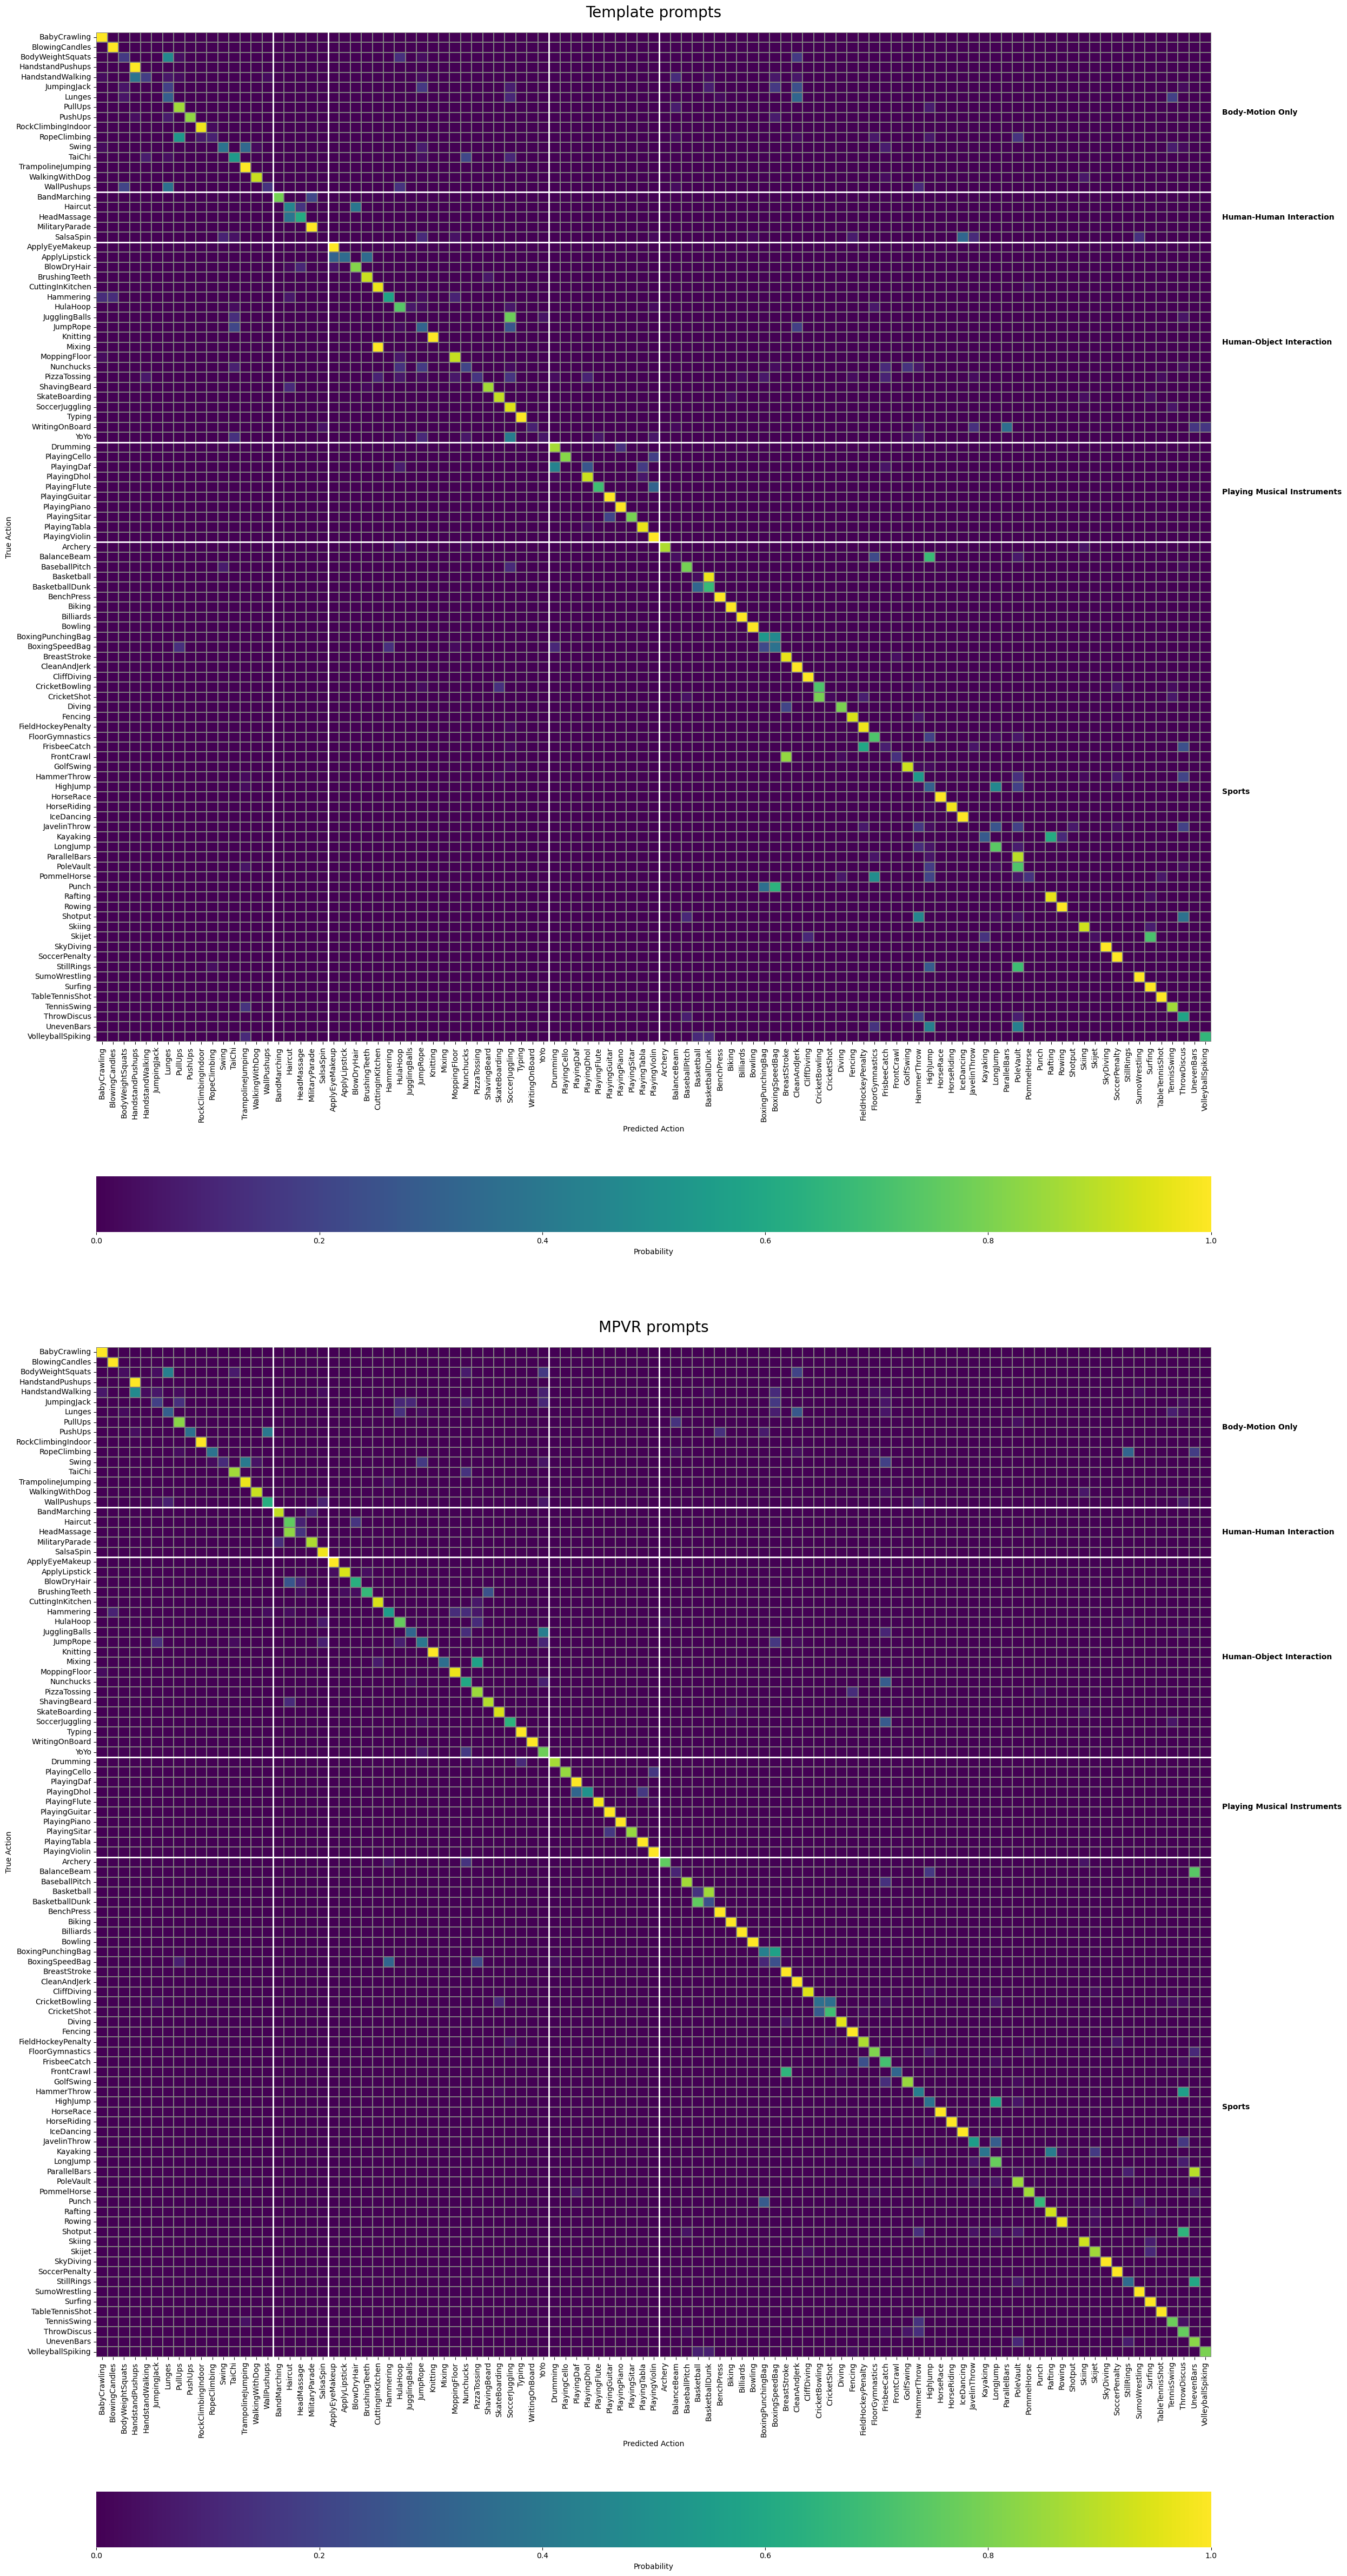

In [6]:
sorted_classes = []
group_boundaries = []
category_ranges = []
current_idx = 0

for category, actions in ucf101_categories_camelcase.items():
    sorted_classes.extend(actions)
    start = current_idx
    current_idx += len(actions)
    end = current_idx

    group_boundaries.append(current_idx)
    category_ranges.append((category, start, end))

# Remove the last boundary (end of the plot)
group_boundaries = group_boundaries[:-1]

def plot_confusion(ax, y_true, y_pred, title):
    # Use sorted_classes to ensure the matrix follows the group order
    cm = confusion_matrix(y_true, y_pred, labels=sorted_classes, normalize="true")

    sns.heatmap(
        cm,
        cmap="viridis",
        xticklabels=sorted_classes,
        yticklabels=sorted_classes,
        ax=ax,
        cbar=True,
        cbar_kws={"orientation": "horizontal", "pad": 0.10, 'label': "Probability"},
        linewidths=0.01,
        linecolor='gray'
    )
    ax.set_title(title, pad=20, fontsize=20)
    ax.set_xlabel("Predicted Action")
    ax.set_ylabel("True Action")

    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.tick_params(axis='y', rotation=0, labelsize=10)

    # Draw thicker white lines to separate the categories
    for boundary in group_boundaries:
        ax.axhline(boundary, color='white', linewidth=2)
        ax.axvline(boundary, color='white', linewidth=2)

    # Add Category Labels on Right Only
    for name, start, end in category_ranges:
        mid_point = (start + end) / 2

        ax.text(
            len(sorted_classes) + 1, mid_point, name,
            ha='left', va='center', rotation=0,
            fontsize=10, fontweight='bold', color='black'
        )

fig, axes = plt.subplots(2, 1, figsize=(25, 50), dpi=100)

plot_confusion(axes[0], df[label_col], df[pred_templates], "Template prompts")
plot_confusion(axes[1], df[label_col], df[pred_mpvr], "MPVR prompts")

plt.tight_layout()
plt.show()

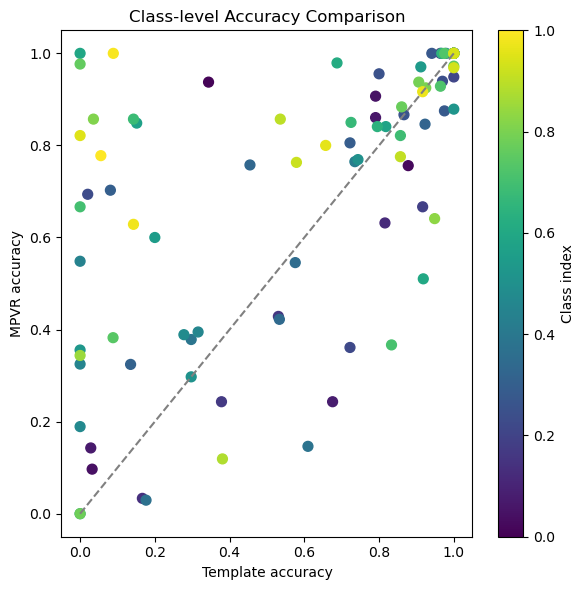

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(
    per_class_acc_temp, per_class_acc_mpvr, c=np.linspace(0, 1, len(acc_df)), s=50
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Template accuracy")
plt.ylabel("MPVR accuracy")
plt.title("Class-level Accuracy Comparison")
plt.colorbar(label="Class index")
plt.tight_layout()
plt.show()

C:\Users\kokos\AppData\Local\Temp\ipykernel_13548\3724449110.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(conditions.keys()), y=list(conditions.values()), palette="Set2")


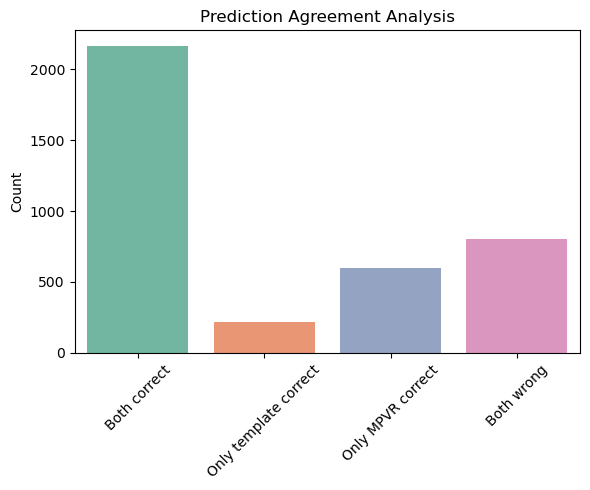

In [8]:
agree_df = pd.DataFrame(
    {
        "temp_correct": df[pred_templates] == df[label_col],
        "mpvr_correct": df[pred_mpvr] == df[label_col],
    }
)

conditions = {
    "Both correct": (agree_df.temp_correct & agree_df.mpvr_correct).sum(),
    "Only template correct": (agree_df.temp_correct & ~agree_df.mpvr_correct).sum(),
    "Only MPVR correct": (~agree_df.temp_correct & agree_df.mpvr_correct).sum(),
    "Both wrong": (~agree_df.temp_correct & ~agree_df.mpvr_correct).sum(),
}

plt.figure(figsize=(6, 5))
sns.barplot(x=list(conditions.keys()), y=list(conditions.values()), palette="Set2")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Prediction Agreement Analysis")
plt.tight_layout()
plt.show()